# BiLSTM-Training auf Artikelebene

Dieses Notebook trainiert einen BiLSTM-Klassifikator auf Artikelebene für Normales vs. Einfaches Deutsch. 
Der Datensatz wird basierend auf der semantischen Ähnlichkeit (Similarity) der Artikelpaare gefiltert.

In [1]:
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import spacy
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURATION ---
CSV_PATH = "../results/information_loss_analysis_cleaned.csv"
MIN_SIM = 0.8  # Mindest-Ähnlichkeit
MAX_SIM = 0.98 # Maximal-Ähnlichkeit

MAX_SEQ_LEN = 512  # Längere Sequenzlänge für ganze Artikel
BATCH_SIZE = 32    # Reduzierte Batch-Größe für längere Sequenzen
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
EPOCHS = 30
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cpu


## 1. Daten laden und filtern

In [2]:
def load_article_data(min_sim, max_sim):
    print(f"Loading article data from {CSV_PATH} with {min_sim} <= similarity <= {max_sim}...")
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"Source file not found: {CSV_PATH}")
        
    df = pd.read_csv(CSV_PATH)
    
    # Filter by similarity
    mask = (df["semantic_similarity_8192"] >= min_sim) & (df["semantic_similarity_8192"] <= max_sim)
    df_filtered = df[mask]
    
    print(f"Found {len(df_filtered)} article pairs matching the criteria.")
    
    X = []
    y = []
    
    # Einfacher Blank-Tokenizer für schnelles Tokenisieren
    nlp = spacy.blank("de")
    
    for _, row in tqdm(df_filtered.iterrows(), total=len(df_filtered), desc="Tokenizing articles"):
        ls_text = str(row["ls_text"])
        as_text = str(row["as_text"])
        
        # Process LS article
        ls_tokens = [t.text.lower() for t in nlp(ls_text) if not t.is_space]
        if len(ls_tokens) >= 10:
            X.append(ls_tokens)
            y.append(1) # Leichte Sprache
            
        # Process AS article
        as_tokens = [t.text.lower() for t in nlp(as_text) if not t.is_space]
        if len(as_tokens) >= 10:
            X.append(as_tokens)
            y.append(0) # Alltags-Sprache
    
    print(f"Total articles loaded: {len(X)} ({y.count(1)} LS, {y.count(0)} AS)")
    
    if len(X) < 20:
        raise ValueError("Not enough data matching the similarity criteria.")
        
    return X, y

X, y = load_article_data(MIN_SIM, MAX_SIM)

Loading article data from ../results/information_loss_analysis_cleaned.csv with 0.8 <= similarity <= 0.98...
Found 1032 article pairs matching the criteria.


Tokenizing articles:   0%|          | 0/1032 [00:00<?, ?it/s]

Total articles loaded: 2060 (1032 LS, 1028 AS)


## 2. Vorbereitung (Klassen & Datasets)

In [3]:
class Vocab:
    def __init__(self, sentences, max_size=25000, min_freq=3):
        counter = Counter()
        for sent in sentences:
            counter.update(sent)
        
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
                
    def __len__(self):
        return len(self.itos)
    
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

class ArticleDataset(Dataset):
    def __init__(self, X, y, vocab, max_len):
        self.X, self.y, self.vocab, self.max_len = X, y, vocab, max_len
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        tokens = self.X[idx]
        encoded = self.vocab.encode(tokens)[:self.max_len]
        padded = encoded + [0] * (self.max_len - len(encoded))
        return torch.tensor(padded, dtype=torch.long), torch.tensor(self.y[idx], dtype=torch.float)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(0.4)
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        return self.fc(self.dropout(hidden))

## 3. Training vorbereiten und ausführen

In [4]:
# Splits erstellen (85% Train/Val, 15% Test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.15, random_state=42, stratify=y_train_val)

# Vokabular aufbauen
vocab = Vocab(X_train)
print(f"Vocab size: {len(vocab)}")

# Dataloaders erstellen
train_ds = ArticleDataset(X_train, y_train, vocab, MAX_SEQ_LEN)
val_ds = ArticleDataset(X_val, y_val, vocab, MAX_SEQ_LEN)
test_ds = ArticleDataset(X_test, y_test, vocab, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

Vocab size: 7027


In [5]:
model = BiLSTMClassifier(len(vocab), EMBEDDING_DIM, HIDDEN_DIM).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

best_val_acc = 0
patience = 7  
counter = 0

model_save_path = f"../results/lstm_article_sim_{MIN_SIM:.2f}_to_{MAX_SIM:.2f}.pt"
history = {'train_loss': [], 'val_loss': [], 'val_bacc': []}

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(batch_x).squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    # Validation
    model.eval()
    preds, targets = [], []
    val_epoch_loss = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            out = model(bx).squeeze()
            val_epoch_loss += criterion(out, by).item()
            preds.extend(torch.round(torch.sigmoid(out)).cpu().numpy())
            targets.extend(by.cpu().numpy())
    
    val_acc = balanced_accuracy_score(targets, preds)
    history['train_loss'].append(epoch_loss / len(train_loader))
    history['val_loss'].append(val_epoch_loss / len(val_loader))
    history['val_bacc'].append(val_acc)
    
    print(f"Epoch {epoch+1} - Loss: {history['train_loss'][-1]:.4f}, Val Loss: {history['val_loss'][-1]:.4f}, Val BAcc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_save_path)
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.6578, Val Loss: 0.5802, Val BAcc: 0.7264


Epoch 2:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2 - Loss: 0.4998, Val Loss: 0.4274, Val BAcc: 0.8256


Epoch 3:   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch 15 - Loss: 0.0902, Val Loss: 0.2153, Val BAcc: 0.9242


Epoch 16:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 16 - Loss: 0.0820, Val Loss: 0.1294, Val BAcc: 0.9621


Epoch 17:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 17 - Loss: 0.0626, Val Loss: 0.1471, Val BAcc: 0.9545
Early stopping triggered.


## 4. Visualisierung der Ergebnisse

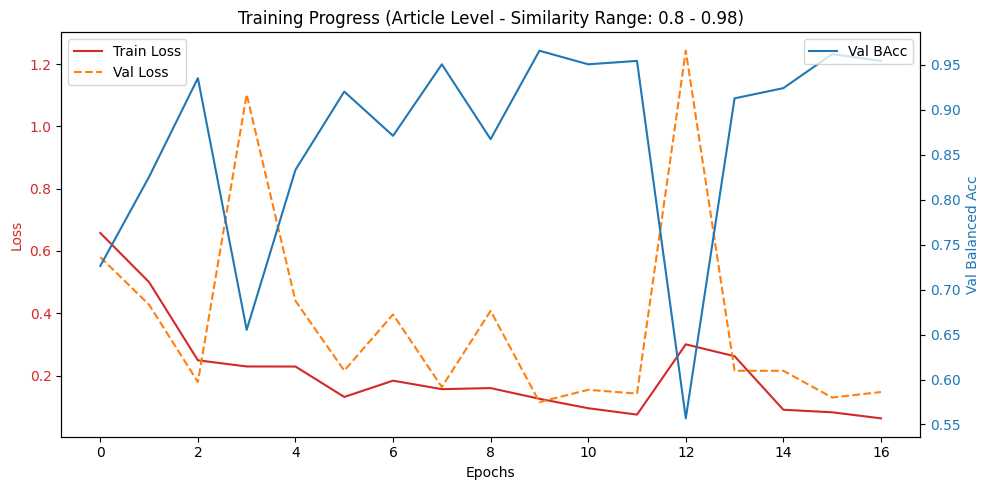

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color=color)
ax1.plot(history['train_loss'], color=color, label='Train Loss')
ax1.plot(history['val_loss'], color='tab:orange', linestyle='--', label='Val Loss')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Val Balanced Acc', color=color)
ax2.plot(history['val_bacc'], color=color, label='Val BAcc')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

plt.title(f'Training Progress (Article Level - Similarity Range: {MIN_SIM} - {MAX_SIM})')
fig.tight_layout()  
plt.show()


## 5. Evaluation auf dem Test-Set


Evaluating on Test Set...

Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95       154
      Simple       0.97      0.92      0.94       155

    accuracy                           0.94       309
   macro avg       0.95      0.95      0.94       309
weighted avg       0.95      0.94      0.94       309



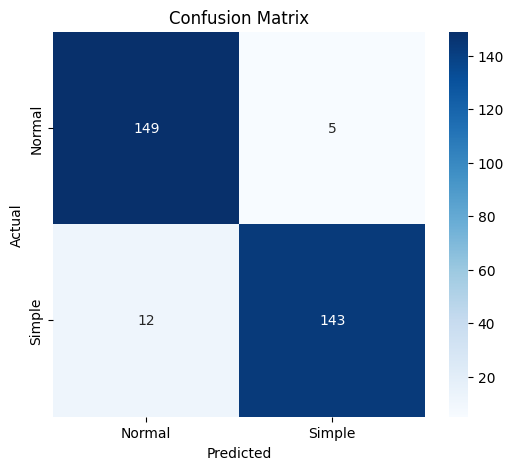

In [7]:
print("\nEvaluating on Test Set...")
if os.path.exists(model_save_path):
    model.load_state_dict(torch.load(model_save_path, map_location=DEVICE))
model.eval()
test_preds, test_targets = [], []
with torch.no_grad():
    for bx, by in test_loader:
        out = model(bx.to(DEVICE)).squeeze()
        test_preds.extend(torch.round(torch.sigmoid(out)).cpu().numpy())
        test_targets.extend(by.numpy())
        
bacc = balanced_accuracy_score(test_targets, test_preds)
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=["Normal", "Simple"]))

# Confusion Matrix
cm = confusion_matrix(test_targets, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Simple"], yticklabels=["Normal", "Simple"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Zusammenfassung speichern
with open("../results/article_experiments_summary.csv", "a") as f:
    f.write(f"{MIN_SIM},{MAX_SIM},{len(X)},{bacc:.4f}\n")


## 6. Evaluation auf externem Lebenshilfe-Datensatz

Hier wird das trainierte Modell direkt auf dem externen Lebenshilfe-Datensatz evaluiert. 
Da dieses Modell auf Artikelebene trainiert wurde, wird der Text direkt als Ganzes klassifiziert.

In [8]:
import json
import spacy
nlp = spacy.blank('de')
import textstat
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report

LH_DATASET_PATH = "../results/lebenshilfe_dataset_no_paragraphs.json"

if not os.path.exists(LH_DATASET_PATH):
    print(f"Lebenshilfe dataset not found at {LH_DATASET_PATH}")
else:
    with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
        lh_data = json.load(f)
        
    def predict_lh_article(text):
        tokens = [t.text.lower() for t in nlp(text) if not t.is_space]
        encoded = vocab.encode(tokens)[:MAX_SEQ_LEN]
        padded = encoded + [0] * (MAX_SEQ_LEN - len(encoded))
        tensor = torch.tensor([padded], dtype=torch.long).to(DEVICE)
        with torch.no_grad():
            output = model(tensor).squeeze()
            prob = torch.sigmoid(output).item()
            pred = 1 if prob > 0.5 else 0
        return pred, prob

    lh_results = []
    for item in tqdm(lh_data, desc="Evaluating Lebenshilfe"):
        ls_text = item.get("ls_text", "")
        as_text = item.get("as_text", "")
        if not ls_text or not as_text:
            continue
            
        ls_pred, ls_prob = predict_lh_article(ls_text)
        as_pred, as_prob = predict_lh_article(as_text)
        
        lh_results.append({
            "LS_Pred": "Simple" if ls_pred == 1 else "Normal",
            "AS_Pred": "Simple" if as_pred == 1 else "Normal",
            "LS_Flesch": textstat.flesch_reading_ease(ls_text),
            "AS_Flesch": textstat.flesch_reading_ease(as_text),
            "LS_Wiener": textstat.wiener_sachtextformel(ls_text, 1),
            "AS_Wiener": textstat.wiener_sachtextformel(as_text, 1),
            "Correct": (ls_pred == 1 and as_pred == 0)
        })

    # Metriken berechnen
    df_lh = pd.DataFrame(lh_results)
    lh_y_true = [1] * len(df_lh) + [0] * len(df_lh)
    lh_y_pred = list(df_lh["LS_Pred"].map({"Simple": 1, "Normal": 0})) + list(df_lh["AS_Pred"].map({"Simple": 1, "Normal": 0}))
    
    lh_acc = accuracy_score(lh_y_true, lh_y_pred)
    lh_bacc = balanced_accuracy_score(lh_y_true, lh_y_pred)
    
    print("\n" + "="*60)
    print(" LEBENSHILFE DATASET EVALUATION (Article-Level Model)")
    print("="*60)
    print(f"Overall Accuracy: {lh_acc*100:.2f}% (Balanced: {lh_bacc*100:.2f}%)")
    print(f"Perfect Pair Match: {df_lh['Correct'].sum()} / {len(df_lh)} ({df_lh['Correct'].mean()*100:.1f}%) - (Both LS & AS correct)")
    print(f"Avg LS Flesch: {df_lh['LS_Flesch'].mean():.2f} (AS: {df_lh['AS_Flesch'].mean():.2f})")
    print(f"Avg LS Wiener: {df_lh['LS_Wiener'].mean():.2f} (AS: {df_lh['AS_Wiener'].mean():.2f})")

Evaluating Lebenshilfe:   0%|          | 0/49 [00:00<?, ?it/s]


 LEBENSHILFE DATASET EVALUATION (Article-Level Model)
Overall Accuracy: 95.92% (Balanced: 95.92%)
Perfect Pair Match: 45 / 49 (91.8%) - (Both LS & AS correct)
Avg LS Flesch: 66.40 (AS: 43.29)
Avg LS Wiener: 5.19 (AS: 9.07)
